## Visualization of dataset


In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


In [3]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Final_Codes


In [4]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)

Found 28 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1807, and number of taxa: 294
Number of unique studies: 28

Sample_id per Category:
Category  n_sample_id
    case         1122
 control          685


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

### Figure 1.b

In [16]:
merged_meta.groupby('Country')['BioProject.Number'].nunique().reset_index(name = 'bioprojects').sort_values('bioprojects', ascending = False)

,Country,bioprojects
2,China,7
11,USA,6
6,New Zealand,3
0,Austria,2
3,Germany,2
7,Poland,2
1,Belgium,1
4,Italy,1
5,Malaysia,1
8,Portugal,1


### Figure 1.c

In [42]:
fig1c = (
    sra_data.groupby('Disease')
    .agg(
        n_bioprojects = ('BioProject.Number', 'nunique'),
        n_sample_id = ('Sample_id', 'nunique')
    )
    .sort_values('n_sample_id', ascending = False)
)
fig1c

,n_bioprojects,n_sample_id
Disease,,
Healthy,18,685
CRS,11,653
AR,5,193
Asthma,4,123
GPA,2,68
CRS + AS,2,34
CF,2,30
RA,2,21


### Figure 1.d


In [117]:
# Family
sample_to_category = sra_data.set_index('Sample_id')['Category']

rel_abu = X.T.copy()
rel_abu = rel_abu.loc[:, rel_abu.columns.get_level_values(1).isin(sample_to_category.index)]
rel_abu = rel_abu.rename(columns=sample_to_category)
rel_abu_by_category = rel_abu.groupby(axis=1, level=1).sum()
rel_abu_by_category['Family'] = [idx.split(';')[4] for idx in rel_abu_by_category.index]
rel_abu_by_category = rel_abu_by_category.groupby('Family').sum()
rel_abu_by_category = rel_abu_by_category.div(rel_abu_by_category.sum(axis=0), axis=1)
rel_abu_by_category.sort_values('case', ascending=False)

Sample_id,case,control
Family,,
f__Corynebacteriaceae,0.178678,0.276292
f__Staphylococcaceae,0.141328,0.146717
f__Enterobacteriaceae,0.116610,0.012181
f__Pseudomonadaceae,0.068266,0.005506
__,0.053716,0.113045
...,...,...
f__BIrii41,0.000016,0.000055
f__Microscillaceae,0.000015,0.000038
f__Sandaracinaceae,0.000014,0.000056


In [161]:
rel_abu = X.T.copy()
rel_abu = rel_abu.loc[:, rel_abu.columns.get_level_values(1).isin(sample_to_category.index)]
rel_abu = rel_abu.rename(columns=sample_to_category)
rel_abu_by_category = rel_abu.sum(axis=1).to_frame('abundance')
rel_abu_by_category['Family'] = [idx.split(';')[4] for idx in rel_abu_by_category.index]
rel_abu_by_category = rel_abu_by_category.groupby('Family').sum()
rel_abu_by_category = rel_abu_by_category.div(rel_abu_by_category.sum(axis=0), axis=1)
rel_abu_by_category.sort_values('abundance', ascending=False)
# rel_abu_by_category.sort_values('abundance', ascending=False).head(3).sum()

,abundance
Family,
f__Corynebacteriaceae,0.215681
f__Staphylococcaceae,0.143371
f__Enterobacteriaceae,0.077023
__,0.076207
f__Propionibacteriaceae,0.045843
...,...
f__BIrii41,0.000031
f__Sandaracinaceae,0.000030
f__Isosphaeraceae,0.000024


In [249]:
### Genus
# Overall:
rel_abu = X.T.copy()
rel_abu = rel_abu.loc[:, rel_abu.columns.get_level_values(1).isin(sample_to_category.index)]
rel_abu = rel_abu.rename(columns=sample_to_category)
rel_abu_overall = rel_abu.sum(axis=1).to_frame('abundance')
rel_abu_overall['Genus'] = [idx.split(';')[5] for idx in rel_abu_overall.index]
rel_abu_overall = rel_abu_overall.groupby('Genus').sum()
rel_abu_overall = rel_abu_overall.div(rel_abu_overall.sum(axis=0), axis=1)
print(rel_abu_overall.loc[['g__Corynebacterium', 'g__Staphylococcus','g__Escherichia-Shigella', 'g__Cutibacterium']].sum(axis = 0))
rel_abu_overall.sort_values('abundance', ascending=False)

# Case / Control
rel_abu = X.T.copy()
rel_abu = rel_abu.loc[:, rel_abu.columns.get_level_values(1).isin(sample_to_category.index)]
rel_abu = rel_abu.rename(columns=sample_to_category)
rel_abu_by_category = rel_abu.groupby(axis=1, level=1).sum()
rel_abu_by_category['Genus'] = [idx.split(';')[5] for idx in rel_abu_by_category.index]
rel_abu_by_category = rel_abu_by_category.groupby('Genus').sum()
rel_abu_by_category = rel_abu_by_category.div(rel_abu_by_category.sum(axis=0), axis=1)
print(rel_abu_by_category.loc[['g__Corynebacterium', 'g__Staphylococcus','g__Escherichia-Shigella', 'g__Cutibacterium']].sum(axis = 0))
rel_abu_by_category.sort_values('case', ascending=False)


abundance    0.451346
dtype: float64
Sample_id
case       0.438218
control    0.472848
dtype: float64


Sample_id,case,control
Genus,,
g__Corynebacterium,0.163495,0.247995
g__Staphylococcus,0.141328,0.146717
__,0.125543,0.171764
g__Escherichia-Shigella,0.105016,0.004832
g__Pseudomonas,0.068266,0.005506
...,...,...
g__Chthoniobacter,0.000013,0.000036
g__Mitsuokella,0.000011,0.000201
g__Pir4_lineage,0.000009,0.000146


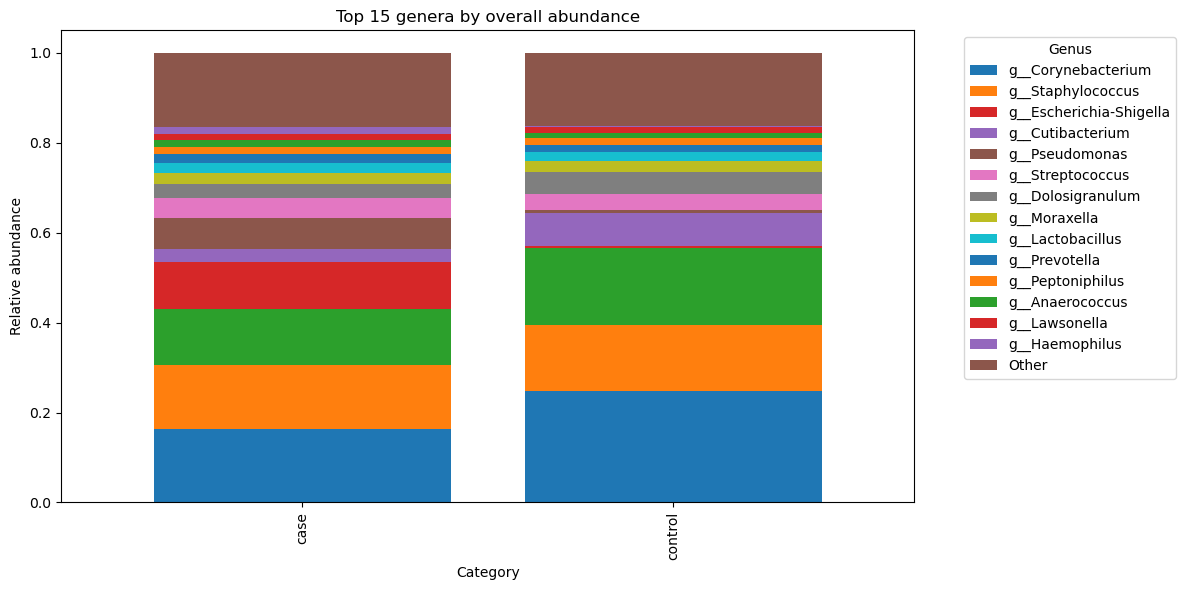

In [160]:
# top 15 genera based on overall abundance
top15 = (rel_abu_overall.sort_values('abundance', ascending=False).head(15).index)

# keep top 15, collapse the rest into "Other"
plot_df = rel_abu_by_category.copy()
plot_df['Genus_plot'] = plot_df.index.where(plot_df.index.isin(top15), 'Other')
plot_df = plot_df.groupby('Genus_plot').sum()

# order bars by the overall ranking, with Other at the end
plot_order = list(top15) + ['Other']
plot_df = plot_df.reindex(plot_order, fill_value=0)

# stacked barplot
ax = plot_df.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    width=0.8
)

ax.set_xlabel('Category')
ax.set_ylabel('Relative abundance')
ax.set_title('Top 15 genera by overall abundance')
ax.legend(title='Genus', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# raw_counts = ra_raw.loc[:, ra_raw.columns.isin(X.index.get_level_values(1).to_list())].T
# raw_counts.index.name = 'Sample_id'
# raw_counts = raw_counts.merge(sra_data, on='Sample_id', how='left')
# raw_counts.to_csv('raw_counts.tsv', sep='\t', index=False)
# Differential abundance use Diff_abundance_testing.R

### Fig 1.e

In [232]:
prevalence = (ra_sub_initial > 0).sum(axis=1) / ra_sub_initial.shape[1]
print(f'Initial shape: {ra_sub.shape}')
n_gt_05 = (prevalence > 0.5).sum()
print(f"Taxa with prevalence > 0.5: {n_gt_05}")
print(f"Taxa with prevalence < 0.01: {(prevalence <= 0.01).sum()}")
print(f"Taxa with prevalence < 0.5: {(prevalence < 0.5).sum()}")
print(f"Taxa with prevalence >= 0.05: {(prevalence >= 0.05).sum()}")


Initial shape: (2240, 1910)
Taxa with prevalence > 0.5: 9
Taxa with prevalence < 0.01: 1486
Taxa with prevalence < 0.5: 2231
Taxa with prevalence >= 0.05: 294


In [283]:
prev_cat = ra_sub_initial.loc[:, ra_sub_initial.columns.isin(sample_to_category.index)]
prev_cat= prev_cat.rename(columns=sample_to_category)
print((prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('case', ascending = False).head(10))

case_prev = (prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('case', ascending = False).head(10)
control_prev = (prev_cat>0).groupby(axis=1, level = 0).mean().sort_values('control', ascending = False).head(10)
case_g = [idx.split(';')[5] for idx in case_prev.index]
control_g = [idx.split(';')[5] for idx in control_prev.index]
print(list(set(case_g)-set(control_g)))
print(list(set(control_g)-set(case_g)))
print(case_g); print(control_g)

                                                        case   control
OTU ID                                                                
d__Bacteria;p__Firmicutes;c__Bacilli;o__Staphyl...  0.892157  0.905109
d__Bacteria;p__Actinobacteriota;c__Actinobacter...  0.848485  0.851095
d__Bacteria;p__Actinobacteriota;c__Actinobacter...  0.727273  0.728467
d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactoba...  0.721925  0.636496
d__Bacteria;p__Firmicutes;c__Clostridia;o__Pept...  0.634581  0.620438
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...  0.629234  0.496350
d__Bacteria;p__Firmicutes;c__Clostridia;o__Pept...  0.568627  0.616058
d__Bacteria;p__Proteobacteria;c__Gammaproteobac...  0.563280  0.548905
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__B...  0.561497  0.484672
d__Bacteria;p__Firmicutes;c__Clostridia;o__Pept...  0.482175  0.527007
[]
[]
['g__Staphylococcus', 'g__Corynebacterium', 'g__Cutibacterium', 'g__Streptococcus', 'g__Anaerococcus', 'g__Pseudomonas', 'g__Peptoniphilus', '

In [ ]:
# bins = np.linspace(0, 1, 61)  # 0, 0.05, ..., 1.0
# counts, edges = np.histogram(prevalence, bins=bins)
# centers = (edges[:-1] + edges[1:]) / 2

# plt.figure(figsize=(6, 10))p
# plt.bar(centers, counts, width=np.diff(edges), align='center')

# plt.xlabel("Prevalence across samples")
# plt.ylabel("Number of taxa")
# plt.ylim(0, 200)

# plt.title("Taxa prevalence distribution (genus-classified taxa only)")
# plt.tight_layout()
# plt.show()

### Figure 1.f